In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA

%matplotlib inline

LOAD THE DATASET

In [2]:
df=pd.read_csv(r'C:\Users\Welcome\Downloads\archive (1) (1).csv')

BASIC OPERATION TO UNDERSTAND THE DATASET

In [3]:
print("First 5 rows:")
display(df.head())

print("Shape of dataset:")
print(df.shape)

print("\nDataset info:")
print(df.info())

print("\nStatistical summary:")
display(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

print("\nColumn names:")
print(df.columns)

First 5 rows:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


Shape of dataset:
(101766, 50)

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-nu

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000



Missing values:
encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                    

HANDLE THE MISSING AND CATAGERICAL FEATURES

In [4]:
df.replace('?',np.nan, inplace=True)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),NaN,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),NaN,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [5]:
df.drop(columns=["weight", "payer_code"], inplace=True, errors='ignore')

In [6]:
print(df.race)

0               Caucasian
1               Caucasian
2         AfricanAmerican
3               Caucasian
4               Caucasian
               ...       
101761    AfricanAmerican
101762    AfricanAmerican
101763          Caucasian
101764          Caucasian
101765          Caucasian
Name: race, Length: 101766, dtype: str


In [7]:
df["race"].isnull()

0         False
1         False
2         False
3         False
4         False
          ...  
101761    False
101762    False
101763    False
101764    False
101765    False
Name: race, Length: 101766, dtype: bool

In [8]:
df["race"] = df["race"].fillna("Unknown")
df["medical_specialty"] = df["medical_specialty"].fillna("Unknown")

In [9]:
df.drop(columns=["encounter_id", "patient_nbr"], inplace=True)

In [10]:

df["readmit_30"] = (df["readmitted"] == "<30").astype(int)

CHECKING FOR THE OUTLIER USING THE BOXPLOT

Index(['admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'number_diagnoses', 'readmit_30'],
      dtype='str')


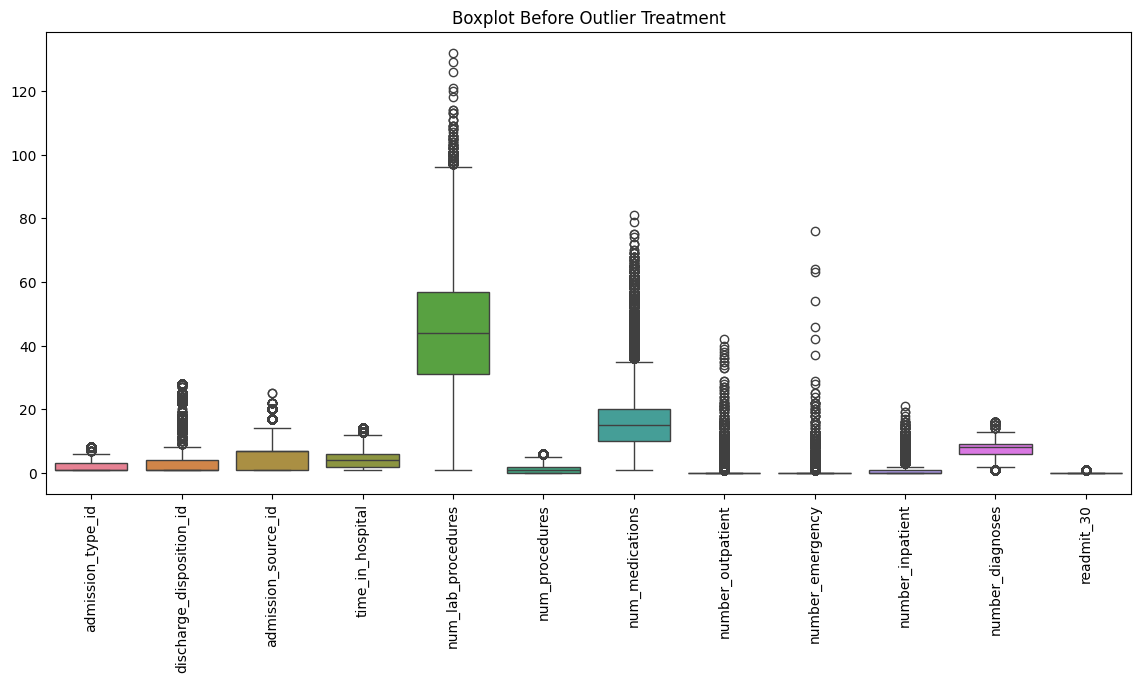

In [11]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
print(num_cols)

plt.figure(figsize=(14, 6))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.title("Boxplot Before Outlier Treatment")
plt.show()

HANDLING HE OUTLIER USING THE IQR

In [12]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower, upper)


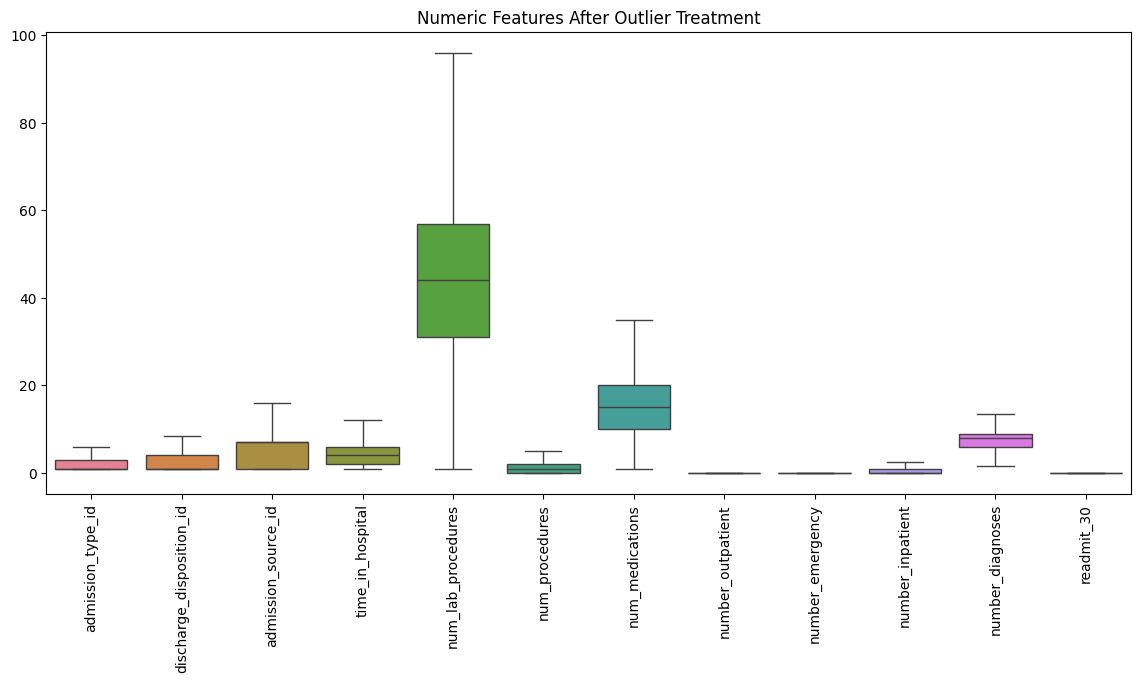

In [13]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.title("Numeric Features After Outlier Treatment")
plt.show()


In [14]:
print("Final dataset shape:", df.shape)
print("Total missing values:", df.isna().sum().sum())
print(df.head())

Final dataset shape: (101766, 47)
Total missing values: 182970
              race  gender      age  admission_type_id  \
0        Caucasian  Female   [0-10)                  6   
1        Caucasian  Female  [10-20)                  1   
2  AfricanAmerican  Female  [20-30)                  1   
3        Caucasian    Male  [30-40)                  1   
4        Caucasian    Male  [40-50)                  1   

   discharge_disposition_id  admission_source_id  time_in_hospital  \
0                       8.5                    1                 1   
1                       1.0                    7                 3   
2                       1.0                    7                 2   
3                       1.0                    7                 2   
4                       1.0                    7                 1   

          medical_specialty  num_lab_procedures  num_procedures  ...  insulin  \
0  Pediatrics-Endocrinology                  41               0  ...       No   
1    

In [15]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
num_cols


Index(['admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'number_diagnoses', 'readmit_30'],
      dtype='str')

OUTLIER CHECK USING Z-SCORE

In [16]:
z_scores = df[num_cols].apply(zscore)
outliers = (z_scores.abs() > 3)

print("Outliers in each numeric column:")
print(outliers.sum().sort_values(ascending=False))



Outliers in each numeric column:
number_diagnoses            281
admission_type_id             0
admission_source_id           0
discharge_disposition_id      0
time_in_hospital              0
num_lab_procedures            0
num_medications               0
num_procedures                0
number_outpatient             0
number_emergency              0
number_inpatient              0
readmit_30                    0
dtype: int64


In [17]:
print("Rows having at least one outlier:")
print(outliers.any(axis=1).sum())


Rows having at least one outlier:
281


In [18]:
print(df.columns)

Index(['race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'medical_specialty', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses',
       'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide',
       'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
       'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton',
       'insulin', 'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted',
       'readmit_30'],
      dtype='str')


In [19]:

numeric_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 
                'num_medications', 'number_outpatient', 'number_emergency', 
                'number_inpatient', 'number_diagnoses']
df_numeric = df[numeric_cols + ['readmit_30']]

In [20]:
df.groupby('readmit_30')[
    ['time_in_hospital',
     'num_medications',
     'number_inpatient',
     'number_emergency']
].mean()

,time_in_hospital,num_medications,number_inpatient,number_emergency
readmit_30,,,,
0,4.363618,15.808512,0.513683,0.0


EDA (UNIVARIATE ANALYSIS)

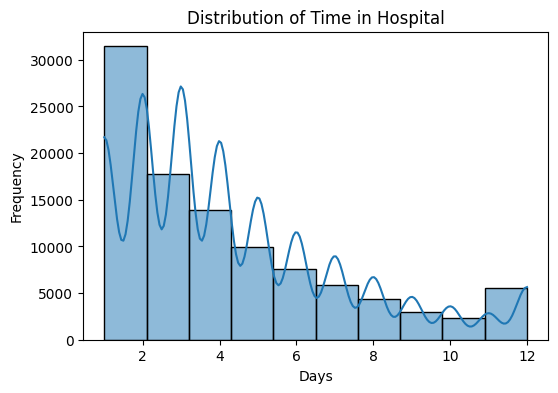

In [63]:

plt.figure(figsize=(6,4))
sns.histplot(df['time_in_hospital'], bins=10, kde=True)
plt.title("Distribution of Time in Hospital")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

🎯 Interpretation

Most patients stay for a short duration, while only a few have longer hospital stays, indicating that long stays are less common.

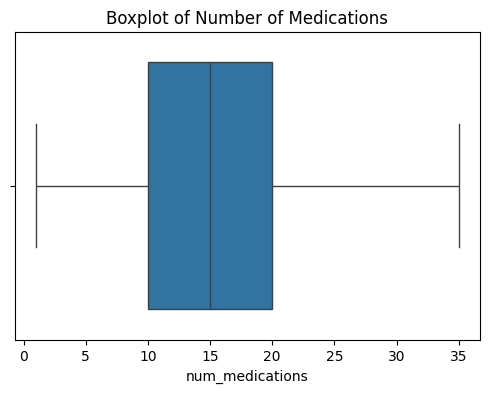

In [64]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['num_medications'])
plt.title("Boxplot of Number of Medications")
plt.show()

🎯 Interpretation

Some patients take significantly more medications than others, indicating possible severe medical conditions.

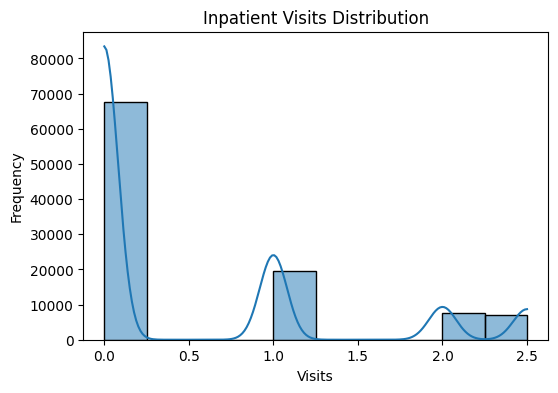

In [65]:
plt.figure(figsize=(6,4))
sns.histplot(df['number_inpatient'], bins=10, kde=True)
plt.title("Inpatient Visits Distribution")
plt.xlabel("Visits")
plt.ylabel("Frequency")
plt.show()

 Interpretation

Most patients have fewer inpatient visits, while a small number of patients frequently visit the hospital.

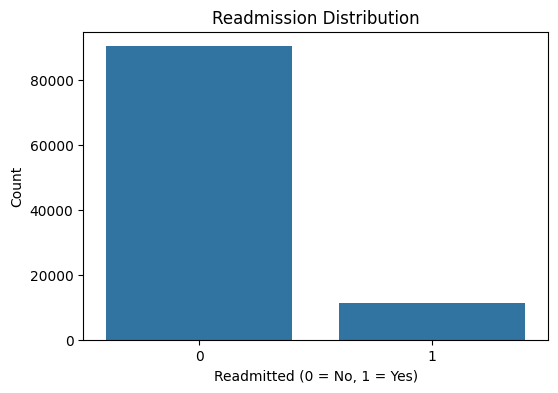

In [67]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['readmit_30'])
plt.title("Readmission Distribution")
plt.xlabel("Readmitted (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

Interpretation

Majority of patients are not readmitted, indicating class imbalance in the dataset.

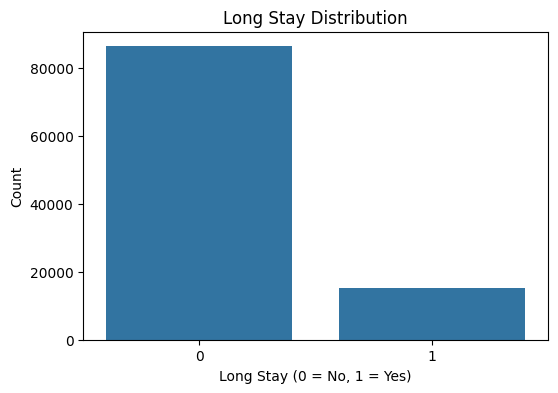

In [68]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['long_stay'])
plt.title("Long Stay Distribution")
plt.xlabel("Long Stay (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

Interpretation

Most patients do not have long stays, but long-stay patients may represent more critical cases.

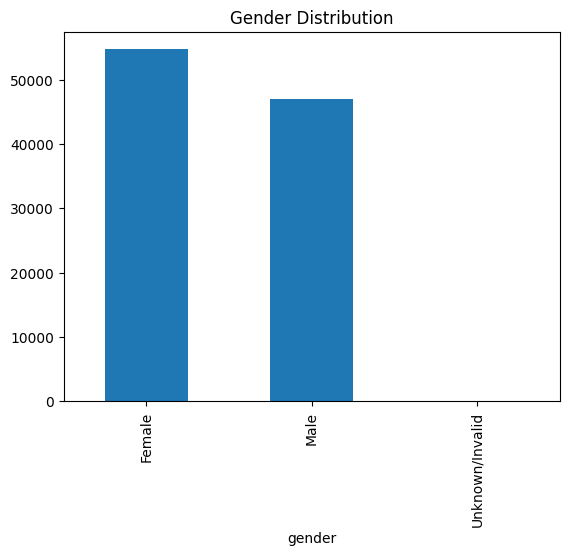

In [25]:
df["gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.show()

INTERPRETATION 

The graph shows the distribution of patients based on gender. It is observed that the number of female patients is slightly higher than male patients. The “Unknown/Invalid” category has very few entries, indicating minimal missing or incorrect gender data in the dataset.

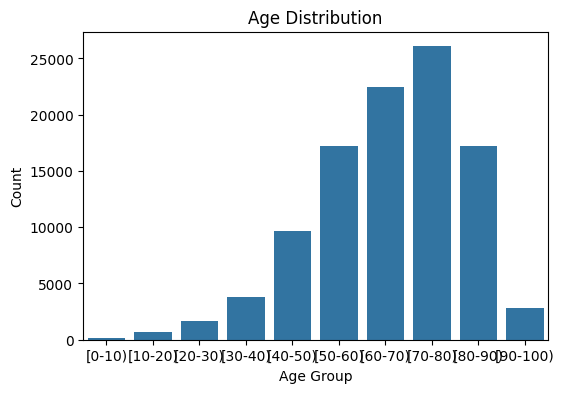

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x=df['age'])
plt.title("Age Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

🎯 Interpretation

Most patients stay for a short duration, while only a few have longer hospital stays, indicating that long stays are less common.

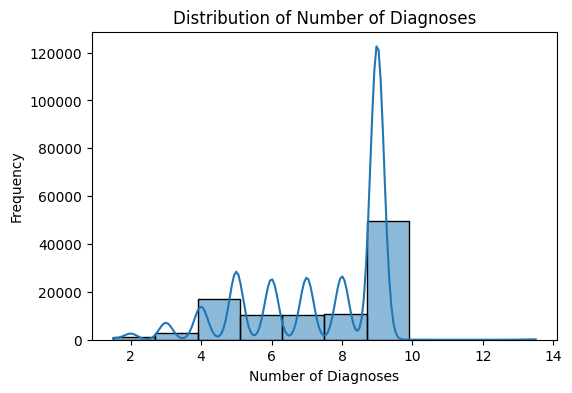

In [69]:
plt.figure(figsize=(6,4))
sns.histplot(df['number_diagnoses'], bins=10, kde=True)
plt.title("Distribution of Number of Diagnoses")
plt.xlabel("Number of Diagnoses")
plt.ylabel("Frequency")
plt.show()

Interpretation

Most patients have a moderate number of diagnoses, while very high diagnosis counts are less frequent, indicating that severe multi-condition cases are limited.

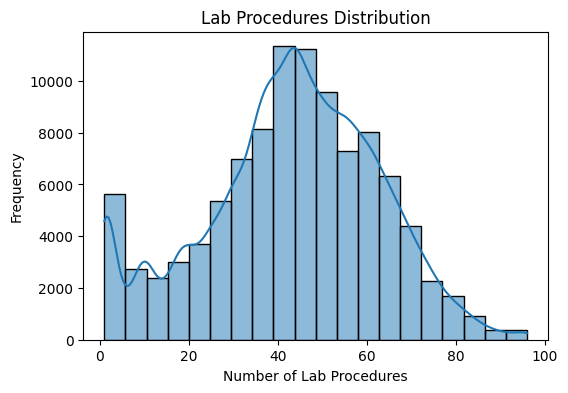

In [70]:
plt.figure(figsize=(6,4))
sns.histplot(df['num_lab_procedures'], bins=20, kde=True)
plt.title("Lab Procedures Distribution")
plt.xlabel("Number of Lab Procedures")
plt.ylabel("Frequency")
plt.show()

Interpretation

The number of lab procedures varies widely among patients, with most patients undergoing a moderate number of tests.

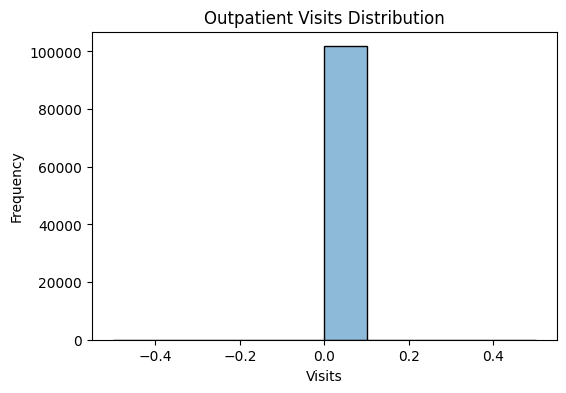

In [71]:
plt.figure(figsize=(6,4))
sns.histplot(df['number_outpatient'], bins=10, kde=True)
plt.title("Outpatient Visits Distribution")
plt.xlabel("Visits")
plt.ylabel("Frequency")
plt.show()

INTERPRETATION

The distribution of outpatient visits shows that the majority of patients have zero outpatient visits. Only a very small number of patients have one or more visits, indicating that outpatient services are not frequently used by most patients.

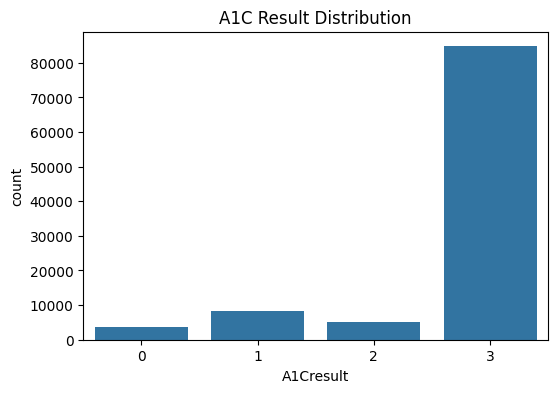

In [72]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['A1Cresult'])
plt.title("A1C Result Distribution")
plt.show()

INTERPRETATION 

The distribution of A1C results shows that the majority of patients fall into category “3”, indicating that most patients do not have a recorded A1C result. Only a small number of patients fall into categories 0, 1, and 2, representing normal or abnormal glucose levels.

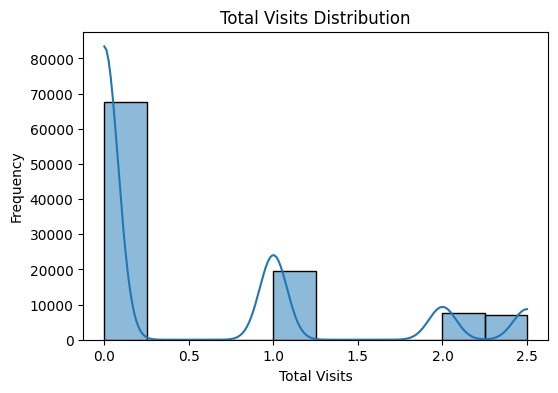

In [73]:
plt.figure(figsize=(6,4))
sns.histplot(df['total_visits'], bins=10, kde=True)
plt.title("Total Visits Distribution")
plt.xlabel("Total Visits")
plt.ylabel("Frequency")
plt.show()

INTERPRETATION 

The distribution of total visits shows that most patients have very few hospital visits, with a large concentration around lower values. Only a small number of patients have higher visit counts, indicating that frequent hospital visits are less common.

In [27]:
print(df["readmit_30"].value_counts())
print(df["readmit_30"].nunique())
print(df["readmit_30"].std())

readmit_30
0    101766
Name: count, dtype: int64
1
0.0


In [28]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
print(numeric_df.isnull().sum())
print(numeric_df.head())

admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
number_diagnoses            0
readmit_30                  0
dtype: int64
   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                       8.5                    1   
1                  1                       1.0                    7   
2                  1                       1.0                    7   
3                  1                       1.0                    7   
4                  1                       1.0                    7   

   time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
0                 1                  41               0                1   
1                 3                  59         

In [29]:
print(df.columns)

Index(['race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'medical_specialty', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses',
       'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide',
       'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
       'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton',
       'insulin', 'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted',
       'readmit_30'],
      dtype='str')


In [30]:
df_check = pd.read_csv(r'C:\Users\Welcome\Downloads\archive (1) (1).csv')
df_check.replace("?", np.nan, inplace=True)

print("Original readmitted values:")
print(df_check["readmitted"].value_counts(dropna=False))

df_check["readmit_30"] = df_check["readmitted"].apply(
    lambda x: 1 if str(x).strip() == "<30" else 0
)

print("\nCorrect readmit_30 values:")
print(df_check["readmit_30"].value_counts())

Original readmitted values:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Correct readmit_30 values:
readmit_30
0    90409
1    11357
Name: count, dtype: int64


In [31]:
df["readmit_30"] = df["readmitted"].apply(
    lambda x: 1 if str(x).strip() == "<30" else 0
)

In [32]:
print(df["readmitted"].value_counts())

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


In [33]:
print(df["readmit_30"].value_counts())

readmit_30
0    90409
1    11357
Name: count, dtype: int64


In [34]:
df.drop(columns=["readmitted"], inplace=True, errors="ignore")

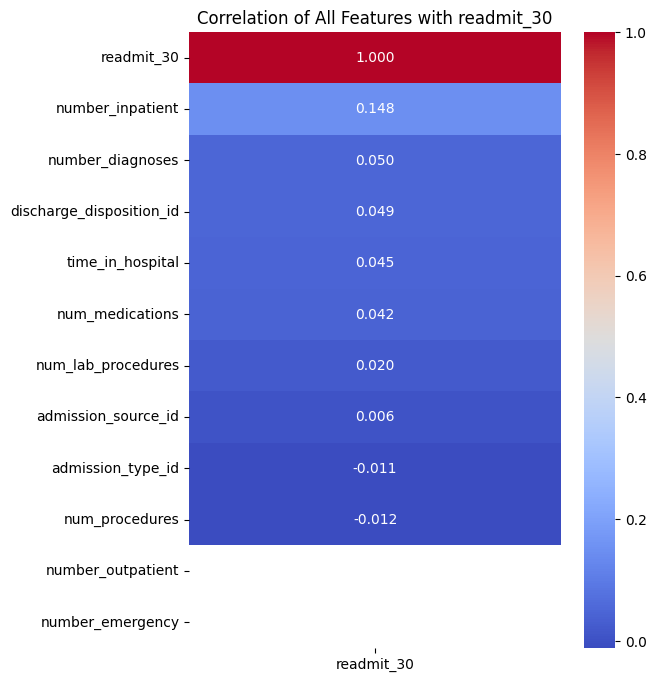

In [35]:
# Select numeric columns
numeric_df = df.select_dtypes(include=['int64','float64'])

# Handle missing values BEFORE correlation
numeric_df = numeric_df.fillna(numeric_df.median())

# Compute correlation
corr_with_target = numeric_df.corr()[["readmit_30"]].sort_values(by="readmit_30", ascending=False)

# Plot heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,8))
sns.heatmap(corr_with_target, annot=True, cmap='coolwarm', fmt=".3f")
plt.title("Correlation of All Features with readmit_30")
plt.show()

EDA (BIVARIATE ANALYSIS)

=== BIVARIATE ANALYSIS: DIABETIC READMISSION PATTERNS ===



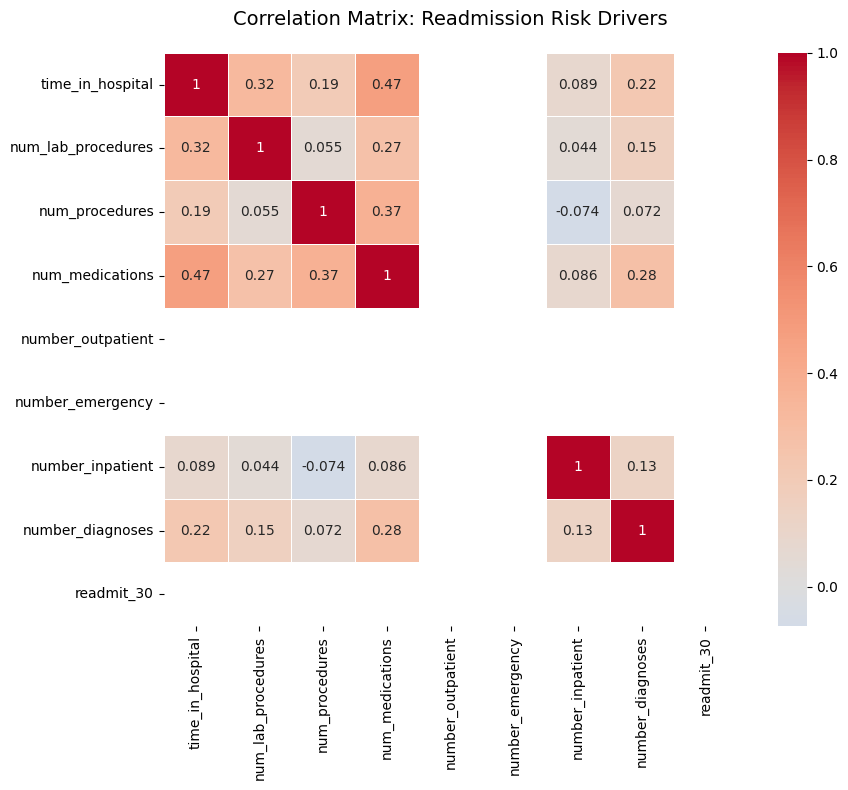

In [36]:
print("=== BIVARIATE ANALYSIS: DIABETIC READMISSION PATTERNS ===\n")

plt.figure(figsize=(10,8))
correlation_matrix = df_numeric.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix: Readmission Risk Drivers', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

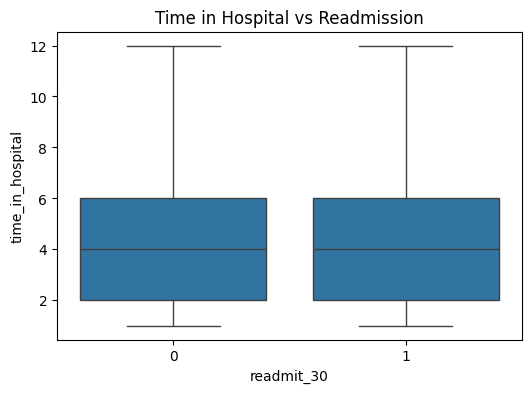

In [74]:
plt.figure(figsize=(6,4))
sns.boxplot(x='readmit_30', y='time_in_hospital', data=df)
plt.title("Time in Hospital vs Readmission")
plt.show()

Interpretation
The boxplot shows that the distribution of hospital stay is very similar for both readmitted and non-readmitted patients. There is no significant difference in median or spread, indicating that hospital stay alone may not strongly influence readmission.

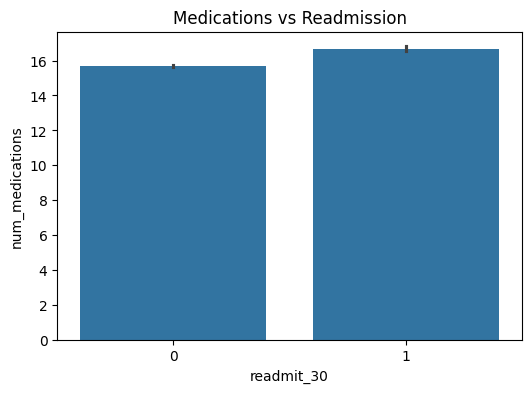

In [75]:
plt.figure(figsize=(6,4))
sns.barplot(x='readmit_30', y='num_medications', data=df)
plt.title("Medications vs Readmission")
plt.show()

INTERPRETATION

The bar chart shows that patients who are readmitted have a slightly higher average number of medications compared to those who are not readmitted. This suggests that patients with more medications may have more complex health conditions, increasing the likelihood of readmission.

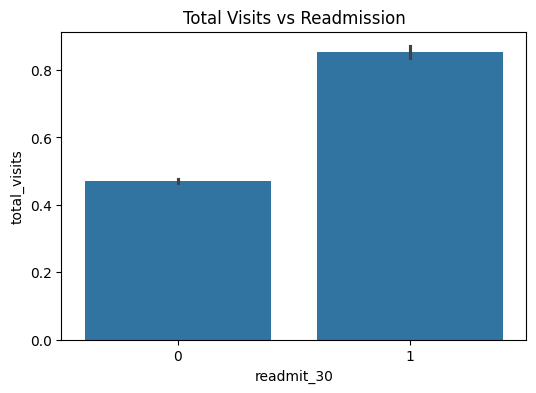

In [76]:
plt.figure(figsize=(6,4))
sns.barplot(x='readmit_30', y='total_visits', data=df)
plt.title("Total Visits vs Readmission")
plt.show()

INTERPRETATION 

The bar chart shows that patients who are readmitted have a significantly higher average number of total visits compared to those who are not readmitted. This indicates that frequent hospital visits are strongly associated with a higher likelihood of readmission.SIMPLE UNDERSTANDING


Readmit = 1 → ~0.85 (higher)
Readmit = 0 → ~0.47 (lower)

✔ Clear difference
✔ Almost double

In [81]:
df['number_emergency'].value_counts()

number_emergency
0    101766
Name: count, dtype: int64

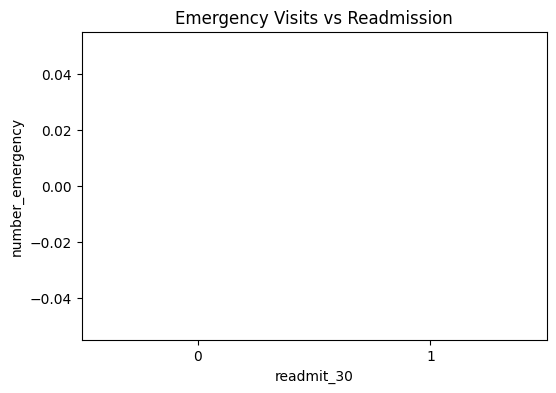

In [77]:
plt.figure(figsize=(6,4))
sns.barplot(x='readmit_30', y='number_emergency', data=df)
plt.title("Emergency Visits vs Readmission")
plt.show()

The graph shows that the number of emergency visits is almost zero for most patients in both readmitted and non-readmitted groups. This indicates that emergency visits are very rare and do not show a significant difference between the two groups.

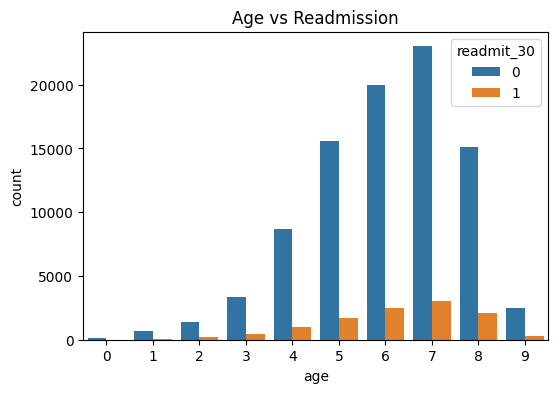

In [78]:
plt.figure(figsize=(6,4))
sns.countplot(x='age', hue='readmit_30', data=df)
plt.title("Age vs Readmission")
plt.show()

INTERPRETATION 

The graph shows that the number of patients increases in higher age groups, and readmission cases are also more frequent in these groups. This indicates that older patients have a higher likelihood of readmission compared to younger patients.Age increases → patient count increases
Readmission (orange bars) also increases with age

✔ Older age → more readmission

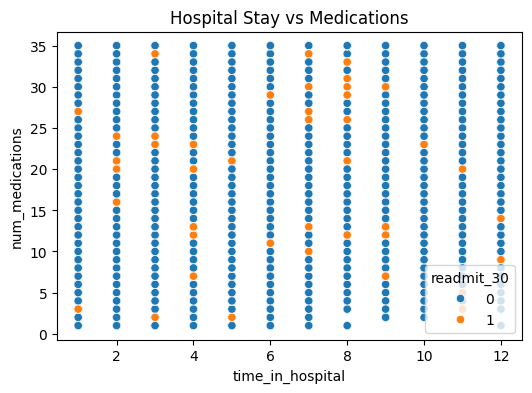

In [79]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='time_in_hospital', y='num_medications', hue='readmit_30', data=df)
plt.title("Hospital Stay vs Medications")
plt.show()

Interpretation

The scatter plot shows the relationship between hospital stay duration and number of medications. The points are widely spread for all hospital stay values, so there is no strong visible trend between these two variables. Readmitted and non-readmitted patients overlap throughout the plot, indicating that these features alone do not clearly separate readmission cases.

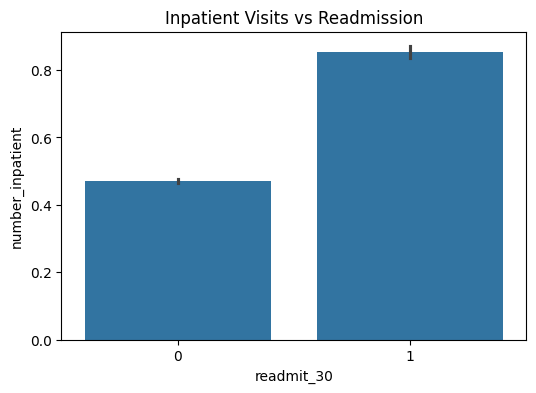

In [80]:
plt.figure(figsize=(6,4))
sns.barplot(x='readmit_30', y='number_inpatient', data=df)
plt.title("Inpatient Visits vs Readmission")
plt.show()

Interpretation

The bar chart shows that patients who are readmitted have a higher average number of inpatient visits compared to those who are not readmitted. This indicates that frequent inpatient visits are associated with a higher likelihood of readmission.Readmit = 1 → ~0.85 (higher)
Readmit = 0 → ~0.47 (lower)

✔ Clear difference
✔ Almost same pattern as total visits

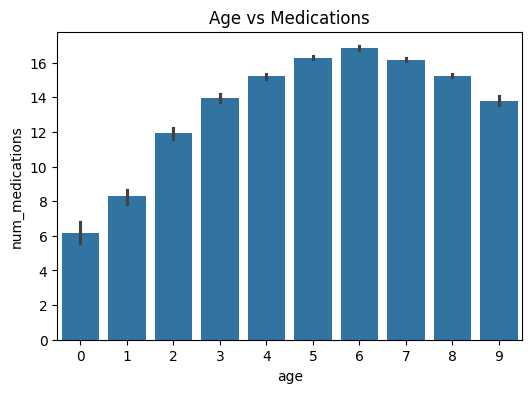

In [82]:
plt.figure(figsize=(6,4))
sns.barplot(x='age', y='num_medications', data=df)
plt.title("Age vs Medications")
plt.show()

INTERPRETATION 

The graph shows that the average number of medications increases with age up to the middle age groups and then slightly decreases in the higher age groups. This indicates that middle-aged patients tend to require more medications compared to younger and older patients.Age 0 → low medications (~6)
Gradually increases → peak around age 5–6 (~16–17)
Then slightly decreases

✔ Pattern = increase → peak → decrease

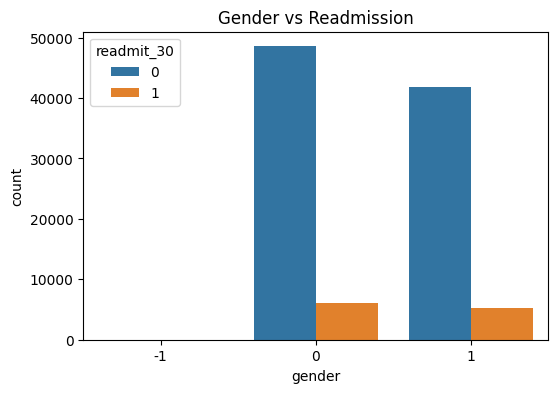

In [83]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='readmit_30', data=df)
plt.title("Gender vs Readmission")
plt.show()

INTERPRETATION 

The graph shows the distribution of readmission across different genders. Both male and female patients have similar readmission patterns, with slightly higher counts for females due to a larger population. This indicates that gender does not have a strong influence on readmission.

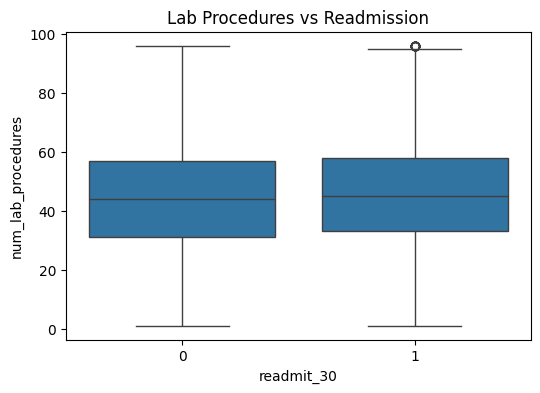

In [84]:
plt.figure(figsize=(6,4))
sns.boxplot(x='readmit_30', y='num_lab_procedures', data=df)
plt.title("Lab Procedures vs Readmission")
plt.show()

Interpretation

WHAT THE GRAPH SHOWS

Both groups (0 and 1):

Median ≈ almost same (~44–46)
Spread (IQR) ≈ very similar
Range ≈ almost equal
Slightly higher values for readmit = 1 (but very small)

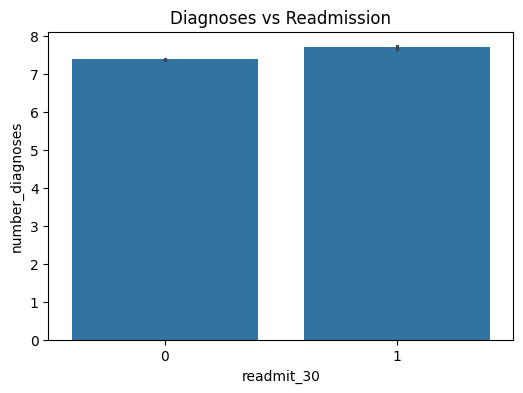

In [85]:
plt.figure(figsize=(6,4))
sns.barplot(x='readmit_30', y='number_diagnoses', data=df)
plt.title("Diagnoses vs Readmission")
plt.show()

Interpretation
The graph shows that the average number of diagnoses is slightly higher for readmitted patients compared to non-readmitted patients. However, the difference is very small, indicating that the number of diagnoses does not have a strong influence on readmission.Readmit = 1 → slightly higher (~7.7)
Readmit = 0 → slightly lower (~7.4)

✔ Difference is very small

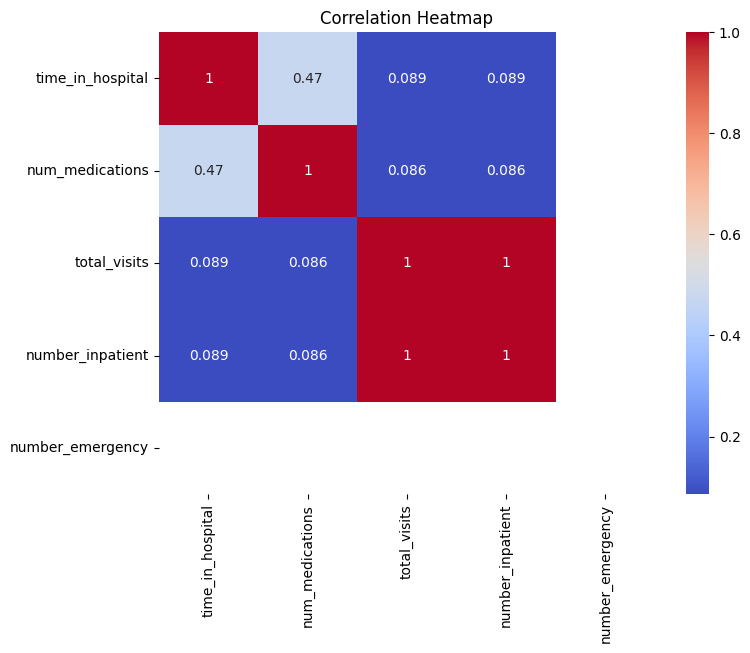

In [86]:
plt.figure(figsize=(8,6))
corr = df[['time_in_hospital','num_medications','total_visits',
           'number_inpatient','number_emergency']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Interpretation

The correlation heatmap shows the relationships between numerical features. A moderate positive correlation is observed between time in hospital and number of medications (~0.47), indicating that patients who stay longer tend to receive more medications. A strong correlation is observed between total visits and number of inpatient visits (~1), suggesting that these features are highly related. Other features show very weak correlations, indicating limited relationships.

In [37]:
print(df.groupby("readmit_30")[[
    "time_in_hospital",
    "num_medications",
    "number_inpatient",
    "number_emergency"
]].mean())

            time_in_hospital  num_medications  number_inpatient  \
readmit_30                                                        
0                   4.317424        15.699499          0.471104   
1                   4.731355        16.676323          0.852646   

            number_emergency  
readmit_30                    
0                        0.0  
1                        0.0  


In [38]:
print("\nEmergency visits vs readmission:")
print(df.groupby("readmit_30")["number_emergency"].mean())


Emergency visits vs readmission:
readmit_30
0    0.0
1    0.0
Name: number_emergency, dtype: float64


In [39]:
print("\nMedications vs readmission:")
print(df.groupby("readmit_30")["num_medications"].mean())


Medications vs readmission:
readmit_30
0    15.699499
1    16.676323
Name: num_medications, dtype: float64


In [40]:
print("\nHospital stay vs readmission:")
print(df.groupby("readmit_30")["time_in_hospital"].mean())


Hospital stay vs readmission:
readmit_30
0    4.317424
1    4.731355
Name: time_in_hospital, dtype: float64


In [41]:
print("\nInpatient visits vs readmission:")
print(df.groupby("readmit_30")["number_inpatient"].mean())



Inpatient visits vs readmission:
readmit_30
0    0.471104
1    0.852646
Name: number_inpatient, dtype: float64


In [42]:
print("\nGender vs readmission:")
print(pd.crosstab(df["gender"], df["readmit_30"], normalize="index"))


Gender vs readmission:
readmit_30              0         1
gender                             
Female           0.887548  0.112452
Male             0.889385  0.110615
Unknown/Invalid  1.000000  0.000000


In [45]:
df['readmit_30'].value_counts()


readmit_30
0    90409
1    11357
Name: count, dtype: int64

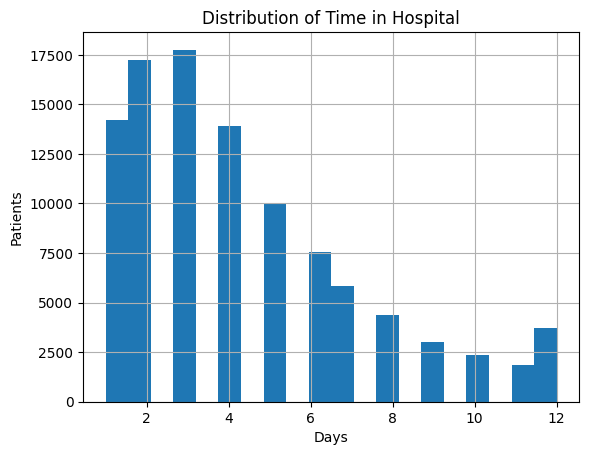

In [46]:
df['time_in_hospital'].hist(bins=20)
plt.xlabel("Days")
plt.ylabel("Patients")
plt.title("Distribution of Time in Hospital")
plt.show()

 FEATURE ENGINEERING

In [47]:
df["total_visits"] = (
    df["number_outpatient"] +
    df["number_emergency"] +
    df["number_inpatient"]
)

df["long_stay"] = (df["time_in_hospital"] > 7).astype(int)

In [48]:
if "insulin" in df.columns:
    print(df["insulin"].unique())

<ArrowStringArray>
['No', 'Up', 'Steady', 'Down']
Length: 4, dtype: str


In [49]:
if "gender" in df.columns:
    df["gender"] = df["gender"].map({"Male": 1, "Female": 0, "Unknown/Invalid": -1})

if "diabetesMed" in df.columns:
    df["diabetesMed"] = df["diabetesMed"].map({"Yes": 1, "No": 0})

if "change" in df.columns:
    df["change"] = df["change"].map({"Ch": 1, "No": 0})

if "insulin" in df.columns:
    print("Insulin unique values:", df["insulin"].unique())

Insulin unique values: <ArrowStringArray>
['No', 'Up', 'Steady', 'Down']
Length: 4, dtype: str


In [50]:
df.to_csv("dashboard_dataset.csv", index=False)

In [51]:
df = df.drop(columns=["readmitted"], errors="ignore")

print("Object columns before encoding:")
print(df.select_dtypes(include="object").columns)

Object columns before encoding:
Index(['race', 'age', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3',
       'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide',
       'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
       'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton',
       'insulin', 'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone'],
      dtype='str')


C:\Users\Welcome\AppData\Local\Temp\ipykernel_4840\4121051506.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include="object").columns)


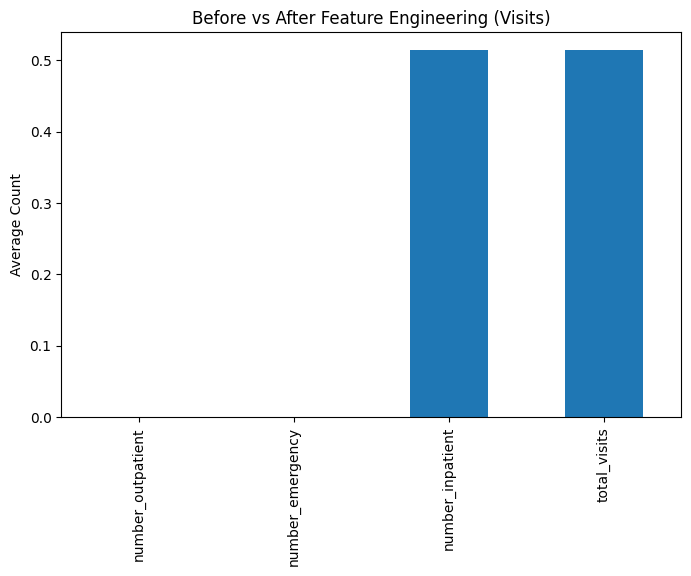

In [87]:
plt.figure(figsize=(8,5))

df[['number_outpatient','number_emergency','number_inpatient','total_visits']].mean().plot(kind='bar')

plt.title("Before vs After Feature Engineering (Visits)")
plt.ylabel("Average Count")
plt.show()

Interpretation
The graph compares the average values of original visit-related features with the engineered feature total_visits. It shows that outpatient and emergency visits have very low averages, while inpatient visits and total visits have higher values. This indicates that the engineered feature effectively combines visit information into a single meaningful variable.

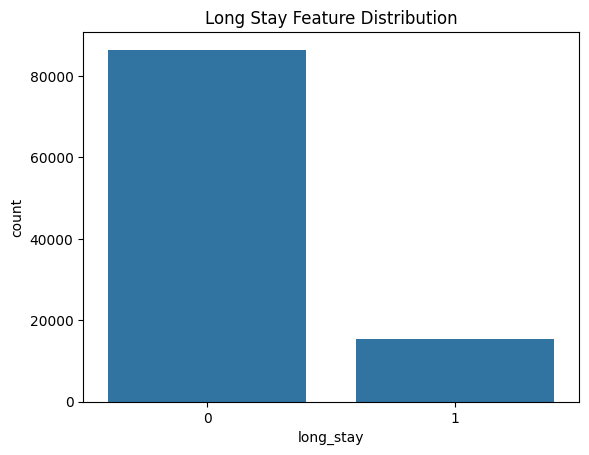

In [88]:
sns.countplot(x='long_stay', data=df)
plt.title("Long Stay Feature Distribution")
plt.show()


Interpretation
The graph shows the distribution of the engineered feature long_stay. Most patients fall under the short stay category (0), while a smaller number of patients have long hospital stays (1). This indicates that long hospital stays are relatively less common in the dataset.

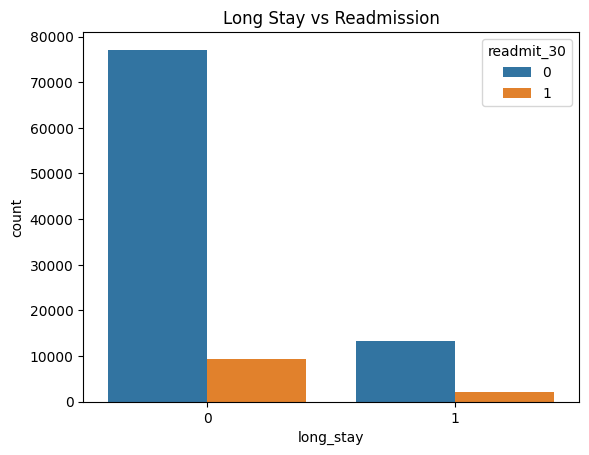

In [89]:
sns.countplot(x='long_stay', hue='readmit_30', data=df)
plt.title("Long Stay vs Readmission")
plt.show()

Interpretation

The graph shows the relationship between long hospital stay and readmission. Although the number of short-stay patients is much higher, both groups show similar proportions of readmission. This indicates that long hospital stay does not significantly increase the likelihood of readmission.

ENCODING CATEGORICAL VARIABLES

In [52]:
le = LabelEncoder()
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print(df.info())

C:\Users\Welcome\AppData\Local\Temp\ipykernel_4840\941555905.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   race                      101766 non-null  int64  
 1   gender                    101766 non-null  int64  
 2   age                       101766 non-null  int64  
 3   admission_type_id         101766 non-null  int64  
 4   discharge_disposition_id  101766 non-null  float64
 5   admission_source_id       101766 non-null  int64  
 6   time_in_hospital          101766 non-null  int64  
 7   medical_specialty         101766 non-null  int64  
 8   num_lab_procedures        101766 non-null  int64  
 9   num_procedures            101766 non-null  int64  
 10  num_medications           101766 non-null  int64  
 11  number_outpatient         101766 non-null  int64  
 12  number_emergency          101766 non-null  int64  
 13  number_inpatient          101766 non-null  float64
 14 

CORRELATION AFTER ENCODING

                          readmit_30
readmit_30                  1.000000
number_inpatient            0.148074
total_visits                0.148074
number_diagnoses            0.049662
discharge_disposition_id    0.049235
time_in_hospital            0.045065
num_medications             0.041583
long_stay                   0.029578
diabetesMed                 0.027125
num_lab_procedures          0.020351
change                      0.019506
age                         0.017634
A1Cresult                   0.016610
repaglinide                 0.010433
medical_specialty           0.010265
admission_source_id         0.006391
diag_3                      0.003301
insulin                     0.002608
diag_2                      0.001207
glipizide                   0.000370
nateglinide                 0.000116
glyburide-metformin        -0.000866
acetohexamide              -0.001111
metformin-pioglitazone     -0.001111
glimepiride-pioglitazone   -0.001111
glipizide-metformin        -0.001245
m

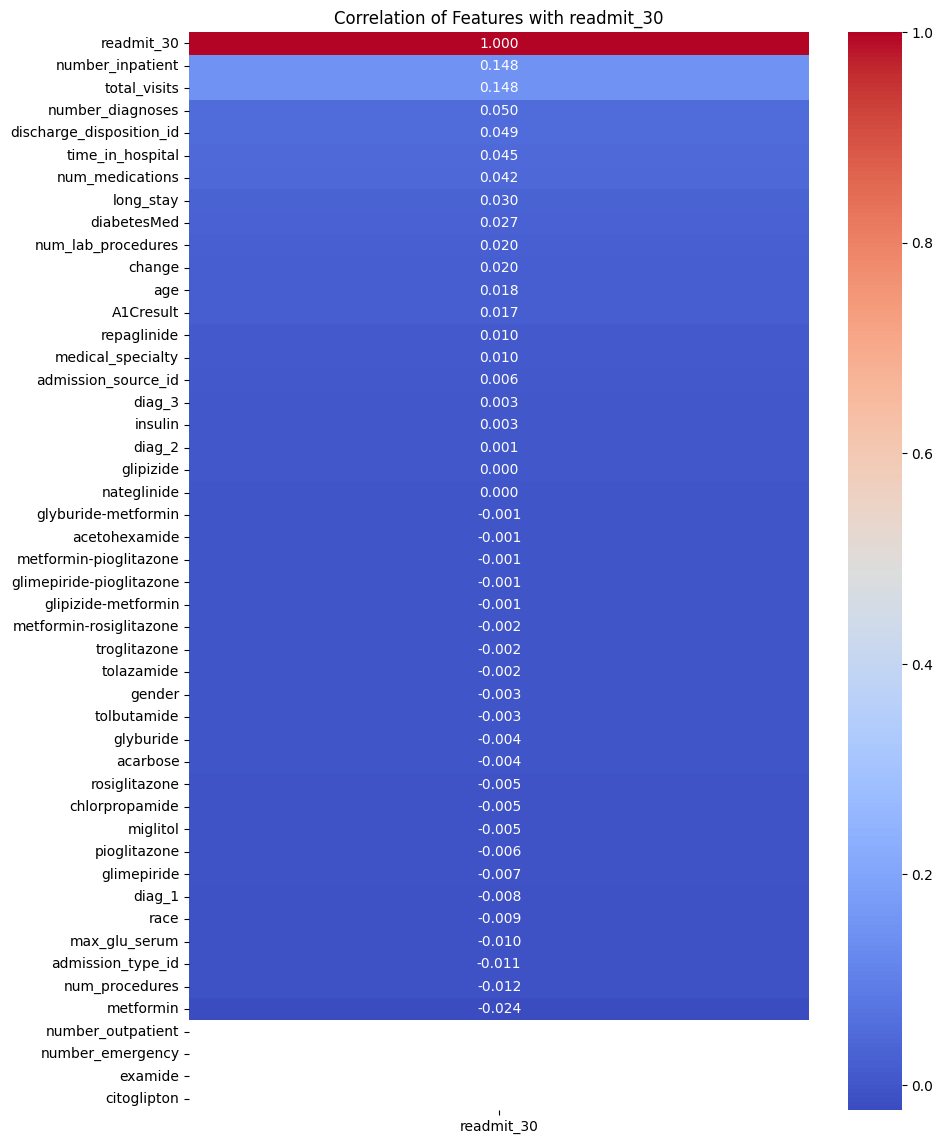

In [53]:
corr = df.corr()[["readmit_30"]].sort_values(by="readmit_30", ascending=False)
print(corr)

plt.figure(figsize=(10, 14))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Correlation of Features with readmit_30")
plt.show()

FEATURE SELECTION

In [54]:
X = df.drop("readmit_30", axis=1)
y = df["readmit_30"]

In [55]:
print(X.isnull().sum())

race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol                    0
troglitazo

In [56]:
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

In [57]:
X = X.fillna(X.mode().iloc[0])

print("Remaining missing values in X:", X.isnull().sum().sum())
print("Shape of X:", X.shape)

Remaining missing values in X: 0
Shape of X: (101766, 47)


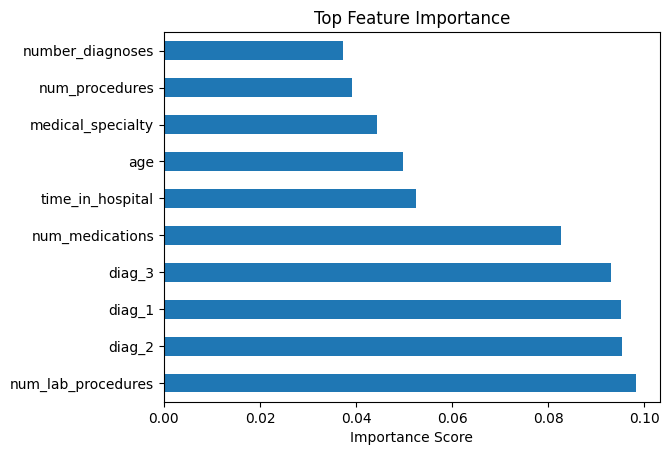

In [90]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

X = df.drop('readmit_30', axis=1)
y = df['readmit_30']

model = RandomForestClassifier()
model.fit(X, y)

importances = model.feature_importances_
feat_importance = pd.Series(importances, index=X.columns)

feat_importance.nlargest(10).plot(kind='barh')
plt.title("Top Feature Importance")
plt.xlabel("Importance Score")
plt.show()

Interpretation

The feature importance graph shows the most influential features in predicting readmission. Features such as number of lab procedures, diagnosis-related features (diag_1, diag_2, diag_3), and number of medications have higher importance scores, indicating they play a significant role in prediction. Other features like age and time in hospital have moderate importance, while some features contribute less.

SELECT KBEST

In [58]:
selector = SelectKBest(score_func=f_classif, k=10)
X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
print("Selected features:", selected_features)

Selected features: Index(['discharge_disposition_id', 'time_in_hospital', 'num_lab_procedures',
       'num_medications', 'number_inpatient', 'number_diagnoses', 'metformin',
       'diabetesMed', 'total_visits', 'long_stay'],
      dtype='str')


c:\Users\Welcome\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [11 12 35 36] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Welcome\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


c:\Users\Welcome\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [11 12 35 36] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Welcome\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


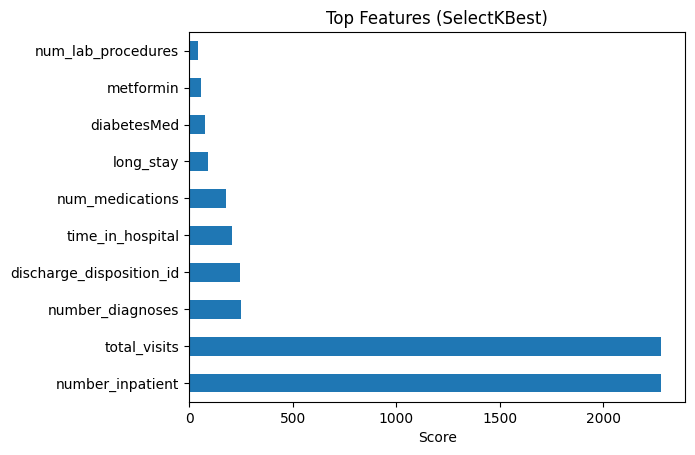

In [91]:
from sklearn.feature_selection import SelectKBest, f_classif

X = df.drop('readmit_30', axis=1)
y = df['readmit_30']

selector = SelectKBest(score_func=f_classif, k=10)
selector.fit(X, y)

scores = pd.Series(selector.scores_, index=X.columns)

scores.nlargest(10).plot(kind='barh')
plt.title("Top Features (SelectKBest)")
plt.xlabel("Score")
plt.show()

Interpretation

The SelectKBest graph shows the top features selected based on statistical tests. Features such as number of inpatient visits and total visits have the highest scores, indicating a strong relationship with readmission. Other features like number of diagnoses, discharge disposition, and time in hospital have moderate importance, while remaining features have lower influence.

SCALING

In [59]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_new)

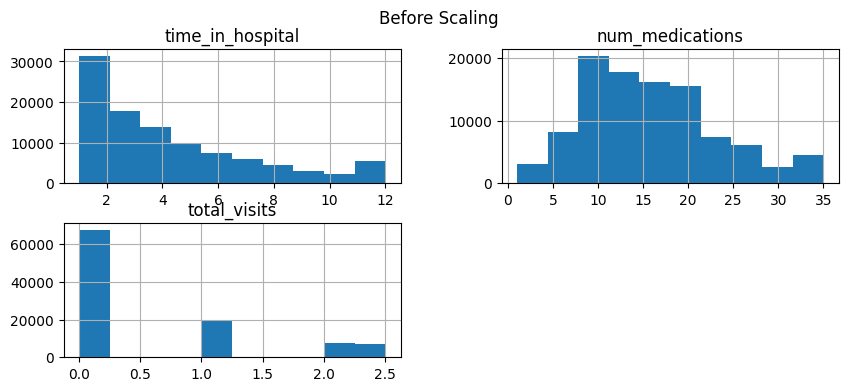

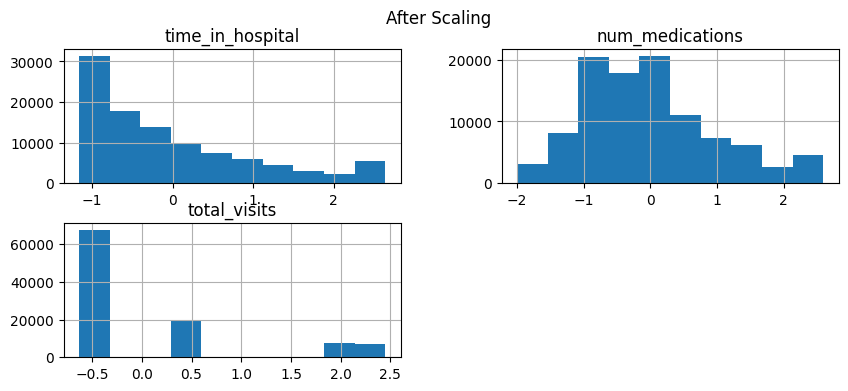

In [92]:
from sklearn.preprocessing import StandardScaler

# Select features
features = ['time_in_hospital','num_medications','total_visits']

# Before scaling
df[features].hist(figsize=(10,4))
plt.suptitle("Before Scaling")
plt.show()

# Apply scaling
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[features])

df_scaled = pd.DataFrame(df_scaled, columns=features)

# After scaling
df_scaled.hist(figsize=(10,4))
plt.suptitle("After Scaling")
plt.show()

Interpretation

Before scaling, features have different ranges and distributions. After scaling, all features are standardized with mean around 0 and similar spread, improving model performance.

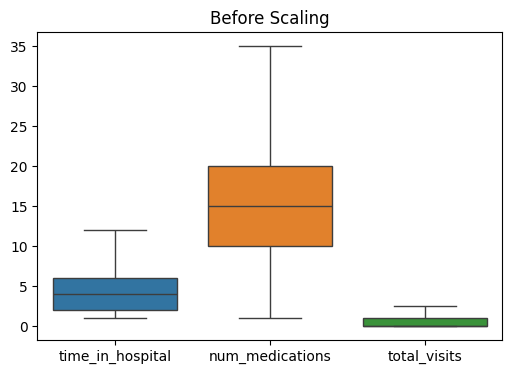

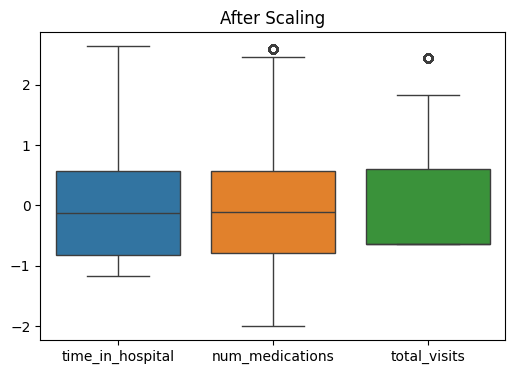

In [93]:
# Before scaling
plt.figure(figsize=(6,4))
sns.boxplot(data=df[features])
plt.title("Before Scaling")
plt.show()

# After scaling
plt.figure(figsize=(6,4))
sns.boxplot(data=df_scaled)
plt.title("After Scaling")
plt.show()

Interpretation

Before scaling, features have different ranges and spread. After scaling, all features are normalized to a similar scale, reducing the effect of outliers and improving comparability.

PCA

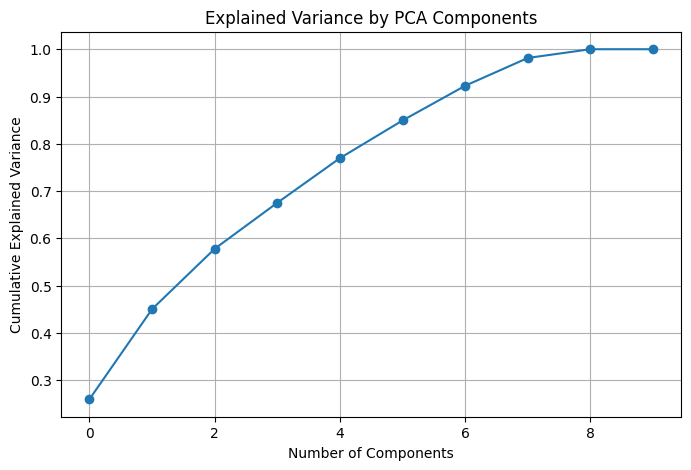

In [60]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.grid(True)
plt.show()

PCA WITH 95% VARIANCE

In [61]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Original Shape:", X_scaled.shape)
print("Reduced Shape:", X_pca.shape)

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

Original Shape: (101766, 10)
Reduced Shape: (101766, 8)

Explained Variance Ratio:
[0.25982164 0.19056901 0.12761463 0.09731611 0.09437216 0.0796721
 0.07342015 0.05875827]


PCA VISUALIZATION

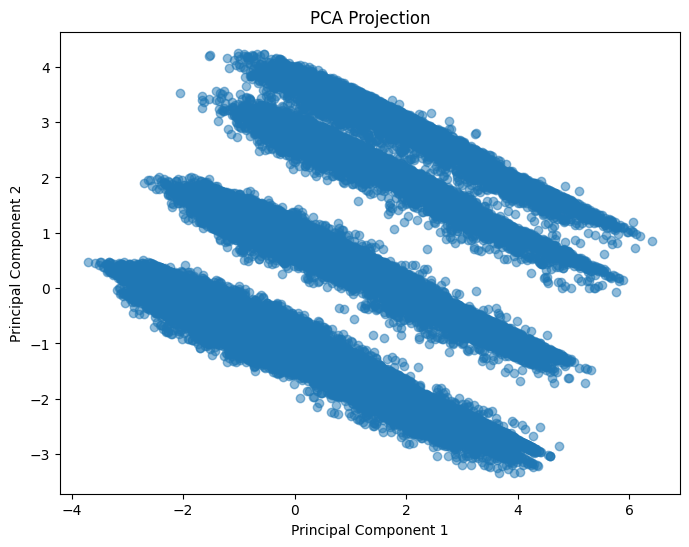

In [62]:
if X_pca.shape[1] >= 2:
    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title("PCA Projection")
    plt.show()
else:
    print("PCA produced only 1 component, so scatter plot cannot be drawn.")